> Process: EDA → preprocessing → baseline model → model selection (CV) → tuning (GridSearchCV) → final evaluation → inference

### 1. Setup

In [3]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.compose import TransformedTargetRegressor

from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

In [5]:
# configuration
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_theme(style="darkgrid")

plt.rcParams.update({
    "axes.titlesize" : 10,
    "axes.labelsize" : 9,
    "xtick.labelsize" :8,
    "ytick.labelsize" :8
})

RANDOM_STATE = 42
CSV_PATH = "insurance.csv"
TARGET_COL = "charges"

### 2. Load data

In [7]:
df = pd.read_csv(CSV_PATH)

In [8]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.924
1,18,male,33.770,1,no,southeast,1725.552
2,28,male,33.000,3,no,southeast,4449.462
3,33,male,22.705,0,no,northwest,21984.471
4,32,male,28.880,0,no,northwest,3866.855


In [9]:
df.shape

(1338, 7)

### 3. Exploratory Data Analysis (EDA)

In [11]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [12]:
# basic dataset overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [13]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Target column: ", TARGET_COL)
print("Numerical column: ", num_cols)
print("Categorical column:", cat_cols)

Target column:  charges
Numerical column:  ['age', 'bmi', 'children', 'charges']
Categorical column: ['sex', 'smoker', 'region']


In [14]:
# missing values analysis
print("\nMissing values per column:")
print(df.isna().sum())


Missing values per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [26]:
# check precence of encoded missing values
for col in df.columns:
    print(df[col].value_counts().head(20))

age
18    69
19    68
50    29
51    29
47    29
46    29
45    29
20    29
48    29
52    29
22    28
49    28
54    28
53    28
21    28
26    28
24    28
25    28
28    28
27    28
Name: count, dtype: int64
sex
male      676
female    662
Name: count, dtype: int64
bmi
32.300    13
28.310     9
30.495     8
30.875     8
31.350     8
30.800     8
34.100     8
28.880     8
33.330     7
35.200     7
25.800     7
32.775     7
27.645     7
32.110     7
38.060     7
25.460     7
30.590     7
27.360     7
24.320     7
34.800     7
Name: count, dtype: int64
children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64
smoker
no     1064
yes     274
Name: count, dtype: int64
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64
charges
1639.563     2
16884.924    1
29330.983    1
2221.564     1
19798.055    1
13063.883    1
13555.005    1
44202.654    1
10422.917    1
7243.814     1
11945.133    1
6311.952     1
1682.59

### Inference: No Missing Values

In [31]:
# duplicates
duplicated_mask = df.duplicated()
num_duplicates = duplicated_mask.sum()
print("Number of duplicated rows:", num_duplicates)

# drop duplicates
df = df.drop_duplicates()
print("Shape after dropping duplicates:", df.shape)

Number of duplicated rows: 1
Shape after dropping duplicates: (1337, 7)


In [33]:
# descriptive stat
df[num_cols].describe()

,age,bmi,children,charges
count,1337.000,1337.000,1337.000,1337.000
mean,39.222,30.663,1.096,13279.121
std,14.044,6.100,1.206,12110.360
min,18.000,15.960,0.000,1121.874
25%,27.000,26.290,0.000,4746.344
50%,39.000,30.400,1.000,9386.161
75%,51.000,34.700,2.000,16657.717
max,64.000,53.130,5.000,63770.428


In [35]:
# descriptive stat
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,1337.000,39.222,14.044,18.000,27.000,39.000,51.000,64.000
bmi,1337.000,30.663,6.100,15.960,26.290,30.400,34.700,53.130
children,1337.000,1.096,1.206,0.000,0.000,1.000,2.000,5.000
charges,1337.000,13279.121,12110.360,1121.874,4746.344,9386.161,16657.717,63770.428


In [39]:
# categorical columns analysis
for col in cat_cols:
    print(df[col].value_counts())

sex
male      675
female    662
Name: count, dtype: int64
smoker
no     1063
yes     274
Name: count, dtype: int64
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64


### Data Visualization

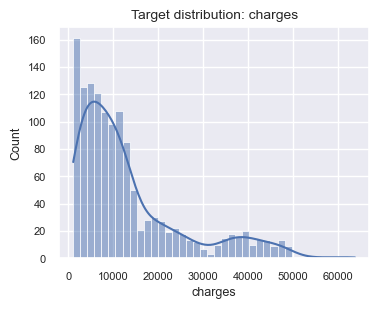

In [42]:
# target column distribution
plt.figure(figsize=(4,3))
sns.histplot(df[TARGET_COL], bins=40, kde=True)
plt.title(f"Target distribution: {TARGET_COL}")
plt.xlabel(TARGET_COL)
plt.show()

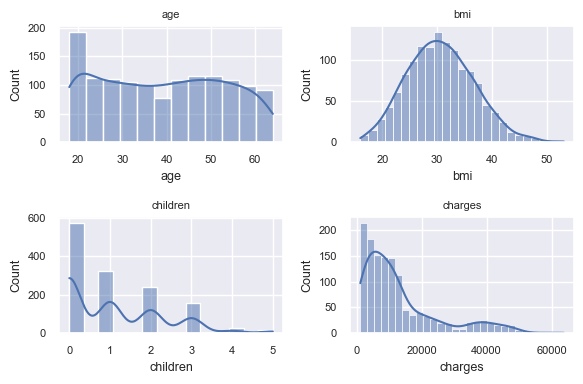

In [44]:
# histogramplot - distribution
fig,axes = plt.subplots(2,2, figsize = (6,4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde = True, ax = axes[i])
    axes[i].set_title(col, fontsize = 8)

plt.tight_layout()
plt.show()

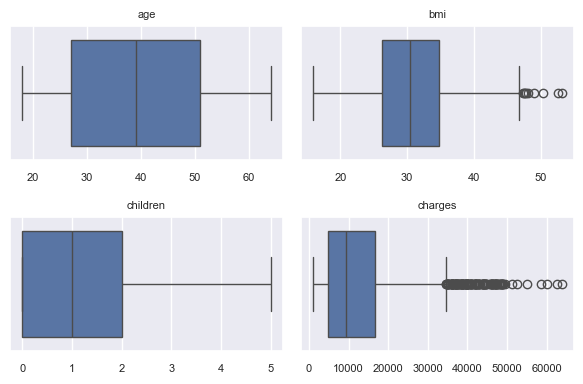

In [50]:
# outliers analysis - boxplot
fig, axes = plt.subplots(2, 2, figsize=(6, 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col, fontsize=8)
    axes[i].set_xlabel("")

plt.tight_layout()
plt.show()

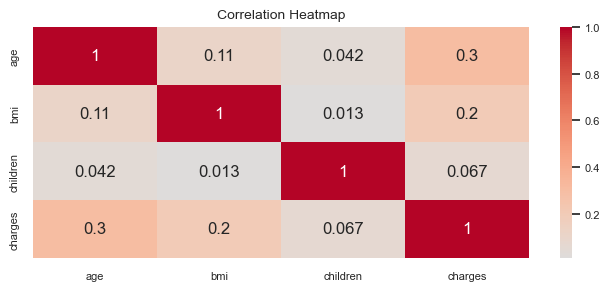

In [52]:
# identify presence of highly correlated columns & feature relationships
plt.figure(figsize=(8,3))
sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

### Note: We don't have much correlated columns

In [55]:
# correlation with target
corr_with_target = df[num_cols].corr()[TARGET_COL].sort_values(ascending = False)
print("\nCorrelation with target:")
print(corr_with_target)


Correlation with target:
charges    1.000
age        0.298
bmi        0.198
children   0.067
Name: charges, dtype: float64


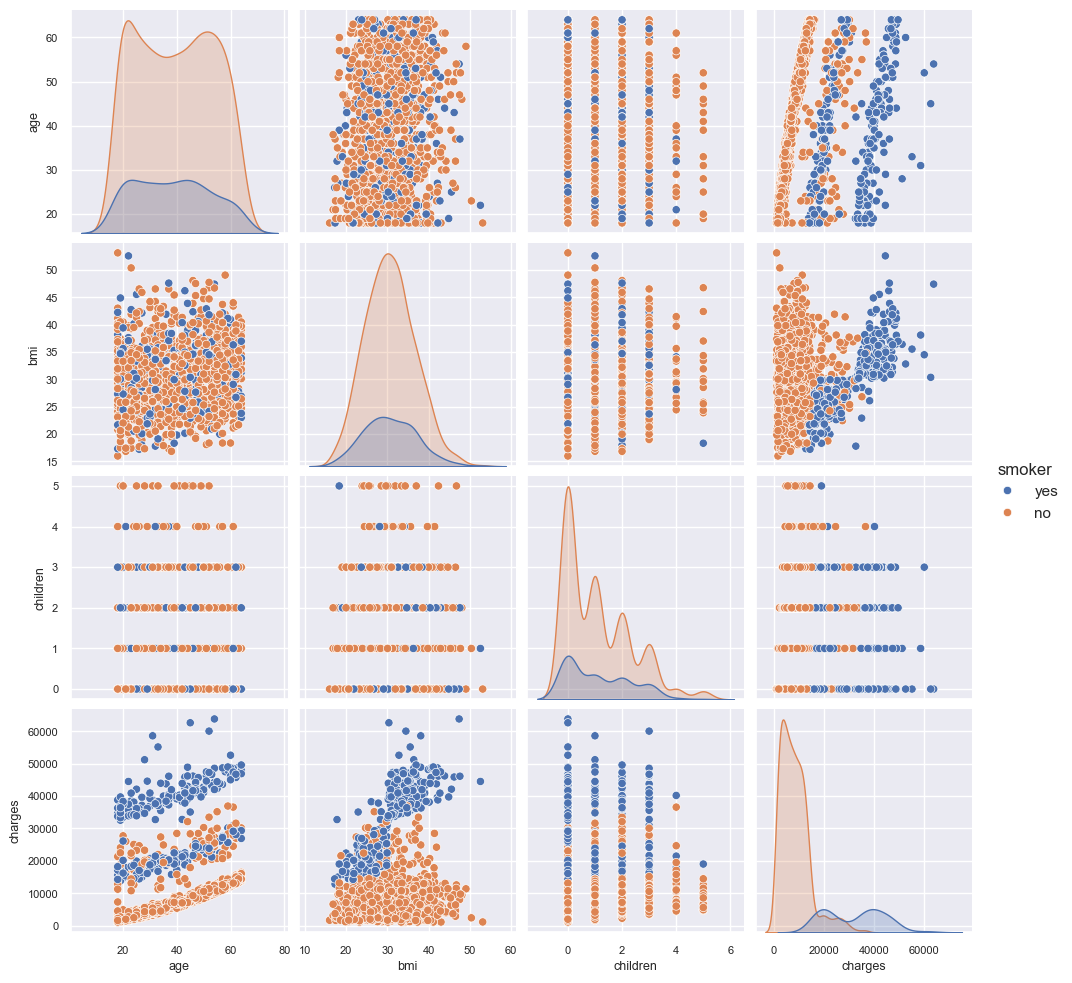

In [57]:
pairplot_cols = num_cols + ["smoker"]

df_pair = df[pairplot_cols].dropna()

sns.pairplot(df_pair, hue="smoker")
plt.show()


---

🔍 Key Insights from EDA
- Dataset contains a mix of numerical features (age, bmi, children) and categorical features (sex, smoker, region)
- No missing values detected in any column
- Target variable charges is highly right-skewed with a small number of extreme high-cost outliers
- Smoker status shows a very strong separation in the charges distribution
- Age and BMI show moderate positive correlation with charges
- No severe multicollinearity among numerical features
- Outliers are prominent in charges (and to a lesser extent BMI), especially for smokers

⸻

🛠️ Preprocessing & Evaluation Plan
- No missing value imputation required
- One-hot encode categorical variables (sex, smoker, region)
- Feature scaling applied for linear and regularized models
- No aggressive outlier removal, to preserve real-world high-cost medical cases
- Use pipelines and ColumnTransformer to prevent data leakage
- Baseline model using Linear Regression
- Model comparison using cross-validation
- Tree-based models explored to capture non-linear relationships
- Apply log transformation on the target variable (charges) to handle skewness
- Primary evaluation metric: MAE (robust to extreme outliers)
- Secondary metrics: RMSE and R² (to understand worst-case errors and variance explained)
- Hyperparameter tuning performed only on top-performing models
- Final evaluation conducted strictly on a held-out test set

---

### 4. Data Preprocessing

In [61]:
# separate features and target
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

In [63]:
X.head()

,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest


In [65]:
y.head()

0   16884.924
1    1725.552
2    4449.462
3   21984.471
4    3866.855
Name: charges, dtype: float64

In [67]:
# train test split
X_train,X_test, y_train,y_test = train_test_split(
    X,
    y,
    random_state=RANDOM_STATE,
    test_size=0.2
)

In [69]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1069, 6)
Test shape: (268, 6)


### Preprocessing Pipeline

In [72]:
numerical_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numerical features: ", numerical_features)
print("Categorical features: ", categorical_features)

# numerical features - preprocessing steps
# imputers can be added in numerical transformer
numerical_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

# categorical features - preprocessing steps
categorical_transformer = Pipeline(
    steps = [
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
        
    ]
)

# preprocessing pipeline
preprocess = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


Numerical features:  ['age', 'bmi', 'children']
Categorical features:  ['sex', 'smoker', 'region']


### 5. Baseline Model(No CV, No Tuning)

In [75]:
baseline_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", LinearRegression())
    ]
    
)

In [77]:
# preprocess the data and train the baseline model
baseline_pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('model', LinearRegression())])

### Evaluation of baseline model

In [82]:
train_baseline_pred = baseline_pipe.predict(X_train)
test_baseline_pred = baseline_pipe.predict(X_test)

In [86]:
train_baseline_pred[:5]

array([ 2326.02453297,  3289.2193497 , 14447.83525029, 16820.71016479,
       10116.72986155])

In [92]:
train_baseline_mae = mean_absolute_error(y_train, train_baseline_pred)
train_baseline_rmse = root_mean_squared_error(y_train, train_baseline_pred)
train_baseline_r2 = r2_score(y_train, train_baseline_pred)

print("\n=== TRAIN BASELINE METRICS (LinearRegression) ===")
print(f"MAE : {train_baseline_mae:.3f}")
print(f"RMSE : {train_baseline_rmse:.3f}")
print(f"R2 : {train_baseline_r2:.3f}")


=== TRAIN BASELINE METRICS (LinearRegression) ===
MAE : 4181.902
RMSE : 6081.107
R2 : 0.730


In [94]:
test_baseline_mae = mean_absolute_error(y_test, test_baseline_pred)
test_baseline_rmse = root_mean_squared_error(y_test, test_baseline_pred)
test_baseline_r2 = r2_score(y_test, test_baseline_pred)

print("\n=== TEST BASELINE METRICS (LinearRegression) ===")
print(f"MAE : {test_baseline_mae:.3f}")
print(f"RMSE : {test_baseline_rmse:.3f}")
print(f"R2 : {test_baseline_r2:.3f}")


=== TEST BASELINE METRICS (LinearRegression) ===
MAE : 4177.046
RMSE : 5956.343
R2 : 0.807


### 6. Model Selection & Optimization

In [97]:
# models to try
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(random_state=RANDOM_STATE,max_iter=10000),
    "DecisionTree": DecisionTreeRegressor(random_state= RANDOM_STATE),
    "RamdomForest": RandomForestRegressor(random_state=RANDOM_STATE),
    "XGBoost": XGBRegressor()
}

In [99]:
k = 5
cv = KFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)

In [101]:
scoring = {
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2"
}

In [103]:
rows = []

for name, model in models.items():
    pipe = Pipeline(
        steps=[
            ("preprocess", preprocess),
            ("model", model)
        ]
    )
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
    rows.append({
        "model": name,
        "cv_mae": -scores["test_mae"].mean(),
        "cv_rmse": -scores["test_rmse"].mean(),
        "cv_r2": scores["test_r2"].mean()        
    })


# sort based on lowest mae value
cv_results = pd.DataFrame(rows).sort_values("cv_mae")
print("=== CV Model Comparison ===")
print(cv_results)

=== CV Model Comparison ===
              model   cv_mae  cv_rmse  cv_r2
4      RamdomForest 2746.510 4898.721  0.820
5           XGBoost 3104.846 5375.649  0.785
3      DecisionTree 3284.183 6777.515  0.659
0  LinearRegression 4221.963 6123.651  0.723
2             Lasso 4221.980 6123.434  0.723
1             Ridge 4226.798 6123.648  0.723


In [105]:
cv_results

,model,cv_mae,cv_rmse,cv_r2
4,RamdomForest,2746.510,4898.721,0.820
5,XGBoost,3104.846,5375.649,0.785
3,DecisionTree,3284.183,6777.515,0.659
0,LinearRegression,4221.963,6123.651,0.723
2,Lasso,4221.980,6123.434,0.723
1,Ridge,4226.798,6123.648,0.723


In [107]:
best_row = cv_results.sort_values("cv_mae").iloc[0]

best_model_name = best_row["model"]
best_mae = best_row["cv_mae"]

print("Best model based on CV MAE:")
print("Model :", best_model_name)
print("CV MAE:", best_mae)

Best model based on CV MAE:
Model : RamdomForest
CV MAE: 2746.5102261642805


### Best Model : RandomForestRegressor

### 7. Hyperparameter Tuning

In [111]:
rf_pipe = Pipeline(
    steps = [
        ("preprocess", preprocess),
        ("model", RandomForestRegressor(
            n_jobs=-1,
            random_state=RANDOM_STATE,
            verbose=1
        ))
    ]
)

In [113]:
# hyperparameters combination
param_grid_rf = {
    "model__n_estimators": [200, 300, 600, 900],
    "model__max_depth": [None, 8, 15, 25],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 0.6, 0.8],
    "model__bootstrap": [True],
}

In [115]:
grid = GridSearchCV(
    estimator=rf_pipe,
    param_grid=param_grid_rf,
    cv=cv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1,
)

In [117]:
# perform grid search
grid.fit(X_train, y_train)

Fitting 5 folds for each of 576 candidates, totalling 2880 fits


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:    0.3s finished


GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         ['age',
                                                                          'bmi',
                                                                          'children']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['sex',
                                                                          'smoker',
                                                                          'region'])])),
                                       ('model',
                                        RandomForestRegressor(n_jobs=-1,
                                                              random_state=42,
                                                              verbose=1))]),
             n_jobs=-1,
             param_grid={'model__bootstrap': [True],
                         'model__max_depth': [None, 8, 15, 25],
                         'model__max_features': ['sqrt', 'log2', 0.6, 0.8],
                         'model__min_samples_leaf': [1, 2, 4],
                         'model__min_samples_split': [2, 5, 10],
                         'model__n_estimators': [200, 300, 600, 900]},
             scoring='neg_mean_absolute_error', verbose=1)

In [118]:
print("\n=== TUNED RF (CV) ===")
print("Best CV MAE:", -grid.best_score_)
print("Best params:", grid.best_params_)


=== TUNED RF (CV) ===
Best CV MAE: 2540.6918653069915
Best params: {'model__bootstrap': True, 'model__max_depth': 8, 'model__max_features': 0.8, 'model__min_samples_leaf': 4, 'model__min_samples_split': 2, 'model__n_estimators': 300}


### 8. Retraining with best params

In [122]:
rf_best = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", RandomForestRegressor(
            bootstrap=True,
            max_depth=8,
            max_features=0.8,
            min_samples_leaf=4,
            min_samples_split=2,
            n_estimators=200,
            n_jobs=-1,
            random_state=RANDOM_STATE,
            verbose=1
        ))
    ]
)

In [124]:
# train best model on entire training data (can also be done with refit=True in grid search)
rf_best.fit(X_train, y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:    0.2s finished


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('model',
                 RandomForestRegressor(max_depth=8, max_features=0.8,
                                       min_samples_leaf=4, n_estimators=200,
                                       n_jobs=-1, random_state=42,
                                       verbose=1))])

In [126]:
train_final_pred = rf_best.predict(X_train)

train_final_rmse = root_mean_squared_error(y_train, train_final_pred)
train_final_mae = mean_absolute_error(y_train, train_final_pred)
train_final_r2 = r2_score(y_train, train_final_pred)

print("\n=== FINAL MODEL (Tuned RF) Train Performance ===")
print(f"MAE : {train_final_mae:.3f}")
print(f"RMSE: {train_final_rmse:.3f}")
print(f"R2  : {train_final_r2:.3f}")


=== FINAL MODEL (Tuned RF) Train Performance ===
MAE : 2009.186
RMSE: 3691.493
R2  : 0.900


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 200 out of 200 | elapsed:    0.0s finished


In [128]:
test_final_pred = rf_best.predict(X_test)

test_final_rmse = root_mean_squared_error(y_test, test_final_pred)
test_final_mae = mean_absolute_error(y_test, test_final_pred)
test_final_r2 = r2_score(y_test, test_final_pred)

print("\n=== FINAL MODEL (Tuned RF) Test Performance ===")
print(f"MAE : {test_final_mae:.3f}")
print(f"RMSE: {test_final_rmse:.3f}")
print(f"R2  : {test_final_r2:.3f}")


=== FINAL MODEL (Tuned RF) Test Performance ===
MAE : 2379.451
RMSE: 4268.656
R2  : 0.901


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 200 out of 200 | elapsed:    0.0s finished


### Apply Log Transformation on Target

In [131]:
rf_best_log = TransformedTargetRegressor(
    regressor=Pipeline(
        steps=[
            ("preprocess", preprocess),
            ("model", RandomForestRegressor(
                bootstrap=True,
                max_depth=8,
                max_features=0.6,
                min_samples_leaf=4,
                min_samples_split=10,
                n_estimators=600,
                n_jobs=-1,
                random_state=RANDOM_STATE
            ))
        ]
    ),
    func=np.log1p,
    inverse_func=np.expm1
)

In [133]:
rf_best_log.fit(X_train, y_train)

TransformedTargetRegressor(func=<ufunc 'log1p'>, inverse_func=<ufunc 'expm1'>,
                           regressor=Pipeline(steps=[('preprocess',
                                                      ColumnTransformer(transformers=[('num',
                                                                                       Pipeline(steps=[('scaler',
                                                                                                        StandardScaler())]),
                                                                                       ['age',
                                                                                        'bmi',
                                                                                        'children']),
                                                                                      ('cat',
                                                                                       Pipeline(steps=[('onehot',
                                                                                                        OneHotEncoder(handle_unknown='ignore'))]),
                                                                                       ['sex',
                                                                                        'smoker',
                                                                                        'region'])])),
                                                     ('model',
                                                      RandomForestRegressor(max_depth=8,
                                                                            max_features=0.6,
                                                                            min_samples_leaf=4,
                                                                            min_samples_split=10,
                                                                            n_estimators=600,
                                                                            n_jobs=-1,
                                                                            random_state=42))]))

### 9. Final Evaluation

In [136]:
train_final_pred = rf_best_log.predict(X_train)

train_final_rmse = root_mean_squared_error(y_train, train_final_pred)
train_final_mae = mean_absolute_error(y_train, train_final_pred)
train_final_r2 = r2_score(y_train, train_final_pred)

print("\n=== FINAL MODEL (Tuned RF) Train Performance ===")
print(f"MAE : {train_final_mae:.3f}")
print(f"RMSE: {train_final_rmse:.3f}")
print(f"R2  : {train_final_r2:.3f}")


=== FINAL MODEL (Tuned RF) Train Performance ===
MAE : 1749.331
RMSE: 4068.462
R2  : 0.879


In [138]:
test_final_pred = rf_best_log.predict(X_test)

test_final_rmse = root_mean_squared_error(y_test, test_final_pred)
test_final_mae = mean_absolute_error(y_test, test_final_pred)
test_final_r2 = r2_score(y_test, test_final_pred)

print("\n=== FINAL MODEL (Tuned RF) Test Performance ===")
print(f"MAE : {test_final_mae:.3f}")
print(f"RMSE: {test_final_rmse:.3f}")
print(f"R2  : {test_final_r2:.3f}")


=== FINAL MODEL (Tuned RF) Test Performance ===
MAE : 1959.913
RMSE: 4284.290
R2  : 0.900


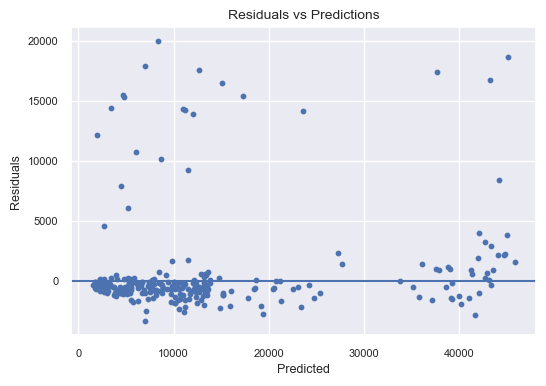

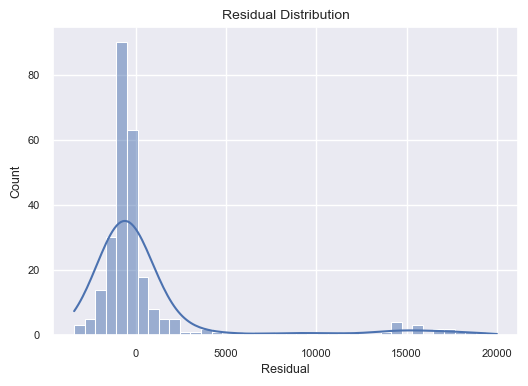

In [140]:
# residual plot
residuals = y_test - test_final_pred

plt.figure(figsize=(6, 4))
plt.scatter(test_final_pred, residuals, s=10)
plt.axhline(0)
plt.title("Residuals vs Predictions")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()

plt.figure(figsize=(6, 4))
sns.histplot(residuals, bins=40, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.show()

### 10. Building a predictive system

In [151]:
def predict_insurance_charges(
    model,
    age: float,
    sex: str,
    bmi: float,
    children: int,
    smoker: str,
    region: str
) -> float:

    new_row = pd.DataFrame([{
        "age": age,
        "sex": sex,           
        "bmi": bmi,           
        "children": children, 
        "smoker": smoker,     
        "region": region     
    }])

    return float(model.predict(new_row)[0])

In [153]:
pred = predict_insurance_charges(
    rf_best_log,
    age=35,
    sex="male",
    bmi=29.5,
    children=2,
    smoker="no",
    region="southeast"
)
print("Predicted Mediacal Insurance cost", round(pred, 2))

Predicted Mediacal Insurance cost 6113.49
